In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix

In [84]:
import os
print(os.getcwd())

f:\updated_model\training


In [121]:
df = pd.read_csv("../data/processed/final_2017.csv")

In [122]:
X = df.drop("Label", axis=1)
y = df["Label"]

In [123]:
print("Total NaN values:", X.isna().sum().sum())

Total NaN values: 162


In [124]:
X.isna().sum()

Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
Total Length of Bwd Packets    0
                              ..
Active Min                     0
Idle Mean                      0
Idle Std                       0
Idle Max                       0
Idle Min                       0
Length: 70, dtype: int64

In [125]:
nan_cols = X.columns[X.isna().any()]
print(nan_cols)

Index(['Flow Bytes/s', 'Flow Packets/s'], dtype='str')


In [126]:
X[nan_cols].isna().sum()

Flow Bytes/s      81
Flow Packets/s    81
dtype: int64

In [127]:
X[X.isna().any(axis=1)]

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
8652,0,1,1,2,6,2,2,2.0,0.000000,6,...,0,24,0.0,0.0,0,0,0.0,0.0,0,0
8931,0,1,1,2,6,2,2,2.0,0.000000,6,...,0,24,0.0,0.0,0,0,0.0,0.0,0,0
9698,0,1,1,2,6,2,2,2.0,0.000000,6,...,0,24,0.0,0.0,0,0,0.0,0.0,0,0
10042,0,1,1,2,6,2,2,2.0,0.000000,6,...,0,24,0.0,0.0,0,0,0.0,0.0,0,0
11069,0,1,1,2,6,2,2,2.0,0.000000,6,...,0,24,0.0,0.0,0,0,0.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52134,0,2,0,0,0,0,0,0.0,0.000000,0,...,0,32,0.0,0.0,0,0,0.0,0.0,0,0
52319,0,2,0,0,0,0,0,0.0,0.000000,0,...,0,32,0.0,0.0,0,0,0.0,0.0,0,0
52475,0,2,0,37,0,31,6,18.5,17.677670,0,...,1,20,0.0,0.0,0,0,0.0,0.0,0,0
52860,0,1,1,6,6,6,6,6.0,0.000000,6,...,0,20,0.0,0.0,0,0,0.0,0.0,0,0


In [128]:
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

In [129]:
print("NaN:", X.isna().sum().sum())
print("Inf:", np.isinf(X).sum().sum())

NaN: 0
Inf: 0


In [130]:
X_normal = X[y == 0]
X_attack = X[y != 0]

In [131]:
from sklearn.model_selection import train_test_split

X_train, X_val = train_test_split(
    X_normal,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

In [132]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [133]:
input_dim = X_train.shape[1]
print("Number of features:", input_dim)

Number of features: 70


In [134]:
X_all = scaler.transform(X)

In [135]:
import tensorflow as tf
from tensorflow import keras
from keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras import regularizers

In [136]:
input_dim = X_train.shape[1]

input_layer = Input(shape=(input_dim,))

In [137]:
def build_autoencoder(input_dim, dropout=0.2, l2=1e-4):
    reg = regularizers.l2(l2)
    bottleneck_dim = max(4, input_dim // 4)

    inp = keras.Input(shape=(input_dim,), name="input")
    x = inp

    # Encoder
    for i, units in enumerate([256, 128, 64]):
        x = layers.Dense(units, kernel_regularizer=reg, name=f"enc{i+1}")(x)
        x = layers.BatchNormalization(name=f"bn_e{i+1}")(x)
        x = layers.Activation("relu", name=f"relu_e{i+1}")(x)
        x = layers.Dropout(dropout, name=f"drop_e{i+1}")(x)

    bottleneck = layers.Dense(
        bottleneck_dim, activation="relu",
        kernel_regularizer=reg, name="bottleneck"
    )(x)

    # Decoder
    x = bottleneck
    for i, units in enumerate([64, 128, 256]):
        x = layers.Dense(units, kernel_regularizer=reg, name=f"dec{i+1}")(x)
        x = layers.BatchNormalization(name=f"bn_d{i+1}")(x)
        x = layers.Activation("relu", name=f"relu_d{i+1}")(x)
        x = layers.Dropout(dropout, name=f"drop_d{i+1}")(x)

    # sigmoid for MinMax-scaled data; swap to 'linear' for StandardScaler
    output = layers.Dense(input_dim, activation="sigmoid", name="output")(x)

    model = keras.Model(inp, output, name="autoencoder")
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="mse",
        metrics=["mae"]
    )
    return model, bottleneck_dim


autoencoder, bottleneck_dim = build_autoencoder(input_dim = X_train.shape[1])
print(f"Bottleneck dim : {bottleneck_dim}")
autoencoder.summary()

Bottleneck dim : 17


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 70)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc1 (Dense)                    │ (None, 256)            │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_e1 (BatchNormalization)      │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_e1 (Activation)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_e1 (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc2 (Dense)                    │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_e2 (BatchNormalization)      │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_e2 (Activation)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_e2 (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc3 (Dense)                    │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_e3 (BatchNormalization)      │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_e3 (Activation)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_e3 (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 17)             │         1,105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec1 (Dense)                    │ (None, 64)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_d1 (BatchNormalization)      │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_d1 (Activation)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_d1 (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec2 (Dense)                    │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_d2 (BatchNormalization)      │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_d2 (Activation)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_d2 (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec3 (Dense)                    │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_d3 (BatchNormalization)      │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_d3 (Activation)            │ (None, 256)            │             

 Total params: 124,503 (486.34 KB)

 Trainable params: 122,711 (479.34 KB)

 Non-trainable params: 1,792 (7.00 KB)

In [138]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=5, min_lr=1e-6, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        "best_autoencoder.keras",
        monitor="val_loss", save_best_only=True, verbose=0
    ),
]

history = autoencoder.fit(
    X_train, X_train,               # input == target
    validation_data=(X_val, X_val),
    epochs=100,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.1068 - mae: 0.1419 - val_loss: 0.0911 - val_mae: 0.1883 - learning_rate: 0.0010
Epoch 2/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0459 - mae: 0.0378 - val_loss: 0.0509 - val_mae: 0.0881 - learning_rate: 0.0010
Epoch 3/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0297 - mae: 0.0293 - val_loss: 0.0368 - val_mae: 0.0629 - learning_rate: 0.0010
Epoch 4/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0197 - mae: 0.0250 - val_loss: 0.0291 - val_mae: 0.0527 - learning_rate: 0.0010
Epoch 5/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0138 - mae: 0.0223 - val_loss: 0.0246 - val_mae: 0.0441 - learning_rate: 0.0010
Epoch 6/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0100 - mae: 0.0203 - val_loss: 0.0207 - val_mae: 0.0392 - learning_rate: 0.0010
Epoch 7/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0074 - mae: 0.0189 - val_loss: 0.0186 - val_mae: 0.0362 - learning_rate: 0.0010
Epoch 8/100
7

In [101]:
import matplotlib.pyplot as plt

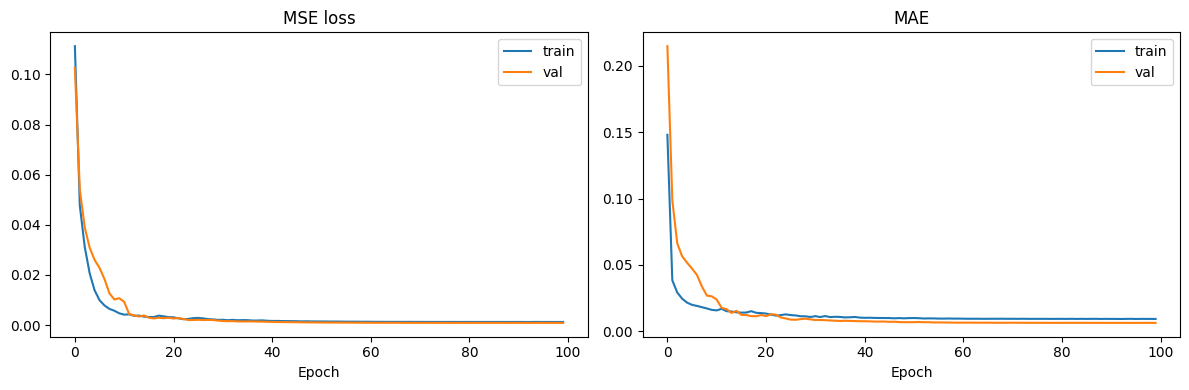

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"],     label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("MSE loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["mae"],     label="train")
axes[1].plot(history.history["val_mae"], label="val")
axes[1].set_title("MAE")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

Val error mean : 0.000393
Val error std  : 0.001734
Threshold      : 0.005594  (μ + 3σ)


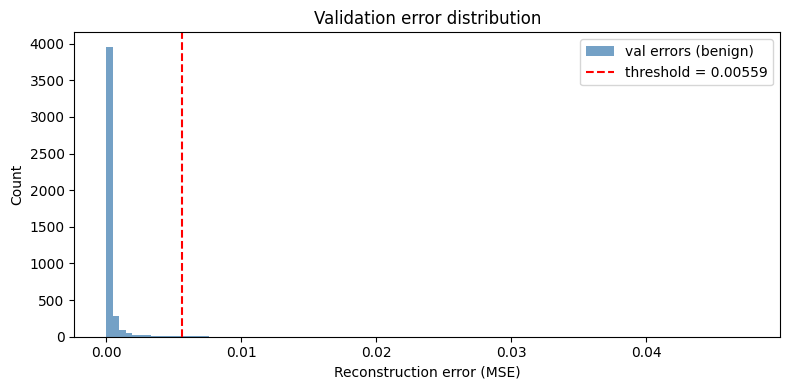

In [103]:
def reconstruction_error(model, X, batch_size=512):
    X_hat = model.predict(X, batch_size=batch_size, verbose=0)
    return np.mean(np.square(X - X_hat), axis=1)


val_errors = reconstruction_error(autoencoder, X_val)
threshold  = val_errors.mean() + 3.0 * val_errors.std()

print(f"Val error mean : {val_errors.mean():.6f}")
print(f"Val error std  : {val_errors.std():.6f}")
print(f"Threshold      : {threshold:.6f}  (μ + 3σ)")

plt.figure(figsize=(8, 4))
plt.hist(val_errors, bins=100, color="steelblue", alpha=0.75, label="val errors (benign)")
plt.axvline(threshold, color="red", linewidth=1.5,
            linestyle="--", label=f"threshold = {threshold:.5f}")
plt.xlabel("Reconstruction error (MSE)")
plt.ylabel("Count")
plt.title("Validation error distribution")
plt.legend()
plt.tight_layout()
plt.show()

In [104]:
from sklearn.metrics import roc_auc_score

In [105]:
y_binary = (y != 0).astype(int)

In [106]:
test_errors = reconstruction_error(autoencoder, X_all)
y_pred      = (test_errors > threshold).astype(int)

print("=" * 55)
print(classification_report(y_binary, y_pred, target_names=["Benign", "Attack"]))

roc_auc = roc_auc_score(y_binary, test_errors)
print(f"ROC-AUC : {roc_auc:.4f}")

              precision    recall  f1-score   support

      Benign       0.51      0.99      0.67     22731
      Attack       0.98      0.35      0.52     33930

    accuracy                           0.61     56661
   macro avg       0.74      0.67      0.59     56661
weighted avg       0.79      0.61      0.58     56661

ROC-AUC : 0.7625


In [107]:
import seaborn as sns

In [108]:
from sklearn.metrics import roc_curve

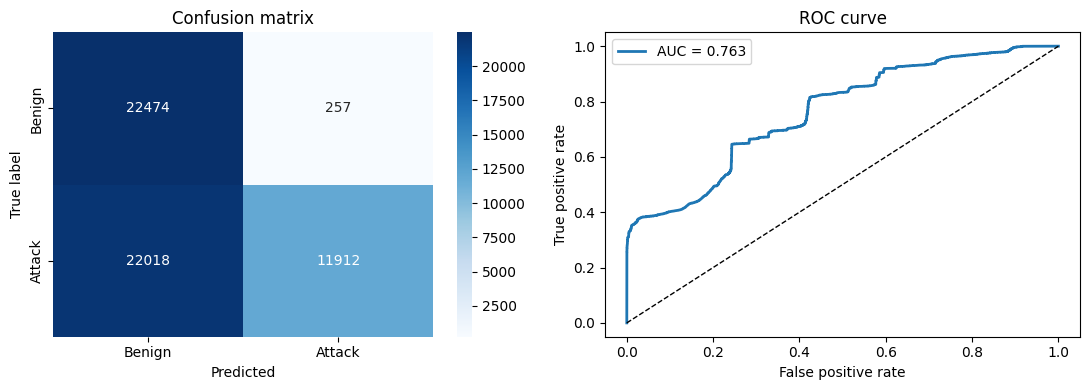

In [109]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Confusion matrix
cm = confusion_matrix(y_binary, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Benign", "Attack"],
            yticklabels=["Benign", "Attack"])
axes[0].set_ylabel("True label")
axes[0].set_xlabel("Predicted")
axes[0].set_title("Confusion matrix")

# ROC curve
fpr, tpr, _ = roc_curve(y_binary, test_errors)
axes[1].plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].set_title("ROC curve")
axes[1].legend()

plt.tight_layout()
plt.savefig("eval_plots.png", dpi=150)
plt.show()

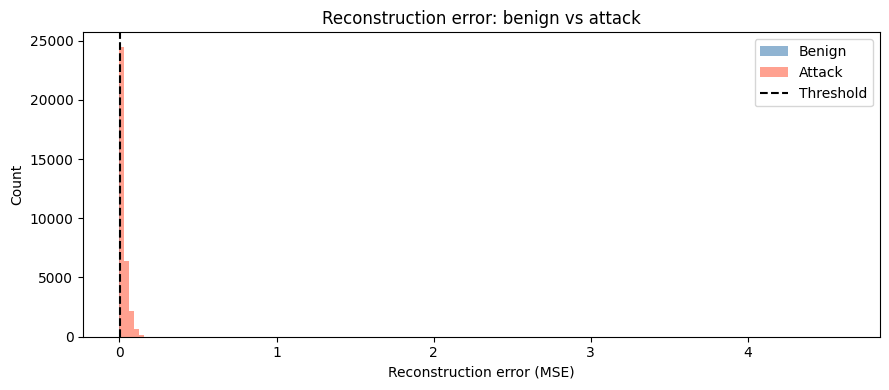

Benign — mean: 0.000387  std: 0.001903
Attack — mean: 0.018036  std: 0.044124


In [110]:
benign_errors = test_errors[y_binary == 0]
attack_errors = test_errors[y_binary == 1]

plt.figure(figsize=(9, 4))
plt.hist(benign_errors, bins=150, alpha=0.6, color="steelblue", label="Benign")
plt.hist(attack_errors, bins=150, alpha=0.6, color="tomato",    label="Attack")
plt.axvline(threshold, color="black", linewidth=1.5,
            linestyle="--", label="Threshold")
plt.xlabel("Reconstruction error (MSE)")
plt.ylabel("Count")
plt.title("Reconstruction error: benign vs attack")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Benign — mean: {benign_errors.mean():.6f}  std: {benign_errors.std():.6f}")
print(f"Attack — mean: {attack_errors.mean():.6f}  std: {attack_errors.std():.6f}")

Current threshold (μ+3σ) : 0.005594
Percentile 90             : 0.000600
Percentile 95             : 0.001339
Percentile 99             : 0.006081


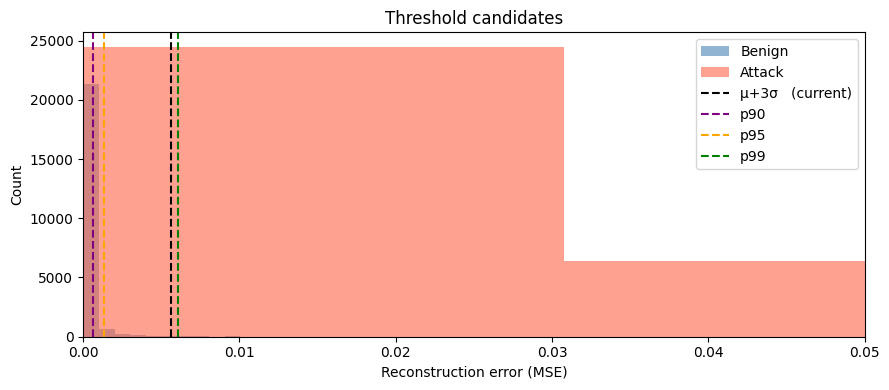

In [111]:
# See your current threshold vs alternatives
print(f"Current threshold (μ+3σ) : {threshold:.6f}")
print(f"Percentile 90             : {np.percentile(val_errors, 90):.6f}")
print(f"Percentile 95             : {np.percentile(val_errors, 95):.6f}")
print(f"Percentile 99             : {np.percentile(val_errors, 99):.6f}")

# Plot multiple candidate thresholds on the error distribution
candidates = {
    "μ+3σ   (current)": threshold,
    "p90"             : np.percentile(val_errors, 90),
    "p95"             : np.percentile(val_errors, 95),
    "p99"             : np.percentile(val_errors, 99),
}

plt.figure(figsize=(9, 4))
plt.hist(benign_errors, bins=150, alpha=0.6, color="steelblue", label="Benign")
plt.hist(attack_errors, bins=150, alpha=0.6, color="tomato",    label="Attack")
colors = ["black", "purple", "orange", "green"]
for (label, val), color in zip(candidates.items(), colors):
    plt.axvline(val, linewidth=1.5, linestyle="--", color=color, label=label)
plt.xlabel("Reconstruction error (MSE)")
plt.ylabel("Count")
plt.title("Threshold candidates")
plt.legend()
plt.xlim(0, 0.05)   # zoom in — errors are clustered near 0
plt.tight_layout()
plt.show()

Best threshold : 0.000024
Best F1        : 0.7927


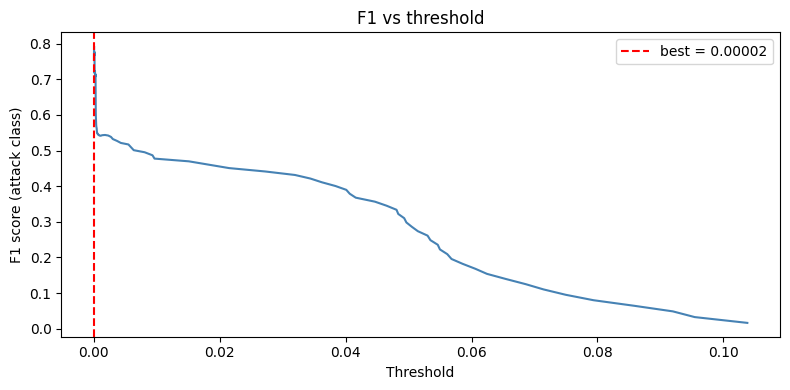

In [112]:
from sklearn.metrics import f1_score

# Compute val errors for benign + a sample of attack rows from test
# (use test set to find best threshold — this is threshold search, not training)
thresholds = np.percentile(test_errors, np.arange(1, 100, 0.5))
f1_scores  = [f1_score(y_binary, (test_errors > t).astype(int)) for t in thresholds]

best_idx       = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1        = f1_scores[best_idx]

print(f"Best threshold : {best_threshold:.6f}")
print(f"Best F1        : {best_f1:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_scores, lw=1.5, color="steelblue")
plt.axvline(best_threshold, color="red", linestyle="--",
            label=f"best = {best_threshold:.5f}")
plt.xlabel("Threshold")
plt.ylabel("F1 score (attack class)")
plt.title("F1 vs threshold")
plt.legend()
plt.tight_layout()
plt.show()

Re-evaluation at threshold = 0.000024
              precision    recall  f1-score   support

      Benign       0.77      0.40      0.53     22731
      Attack       0.70      0.92      0.79     33930

    accuracy                           0.71     56661
   macro avg       0.73      0.66      0.66     56661
weighted avg       0.73      0.71      0.69     56661



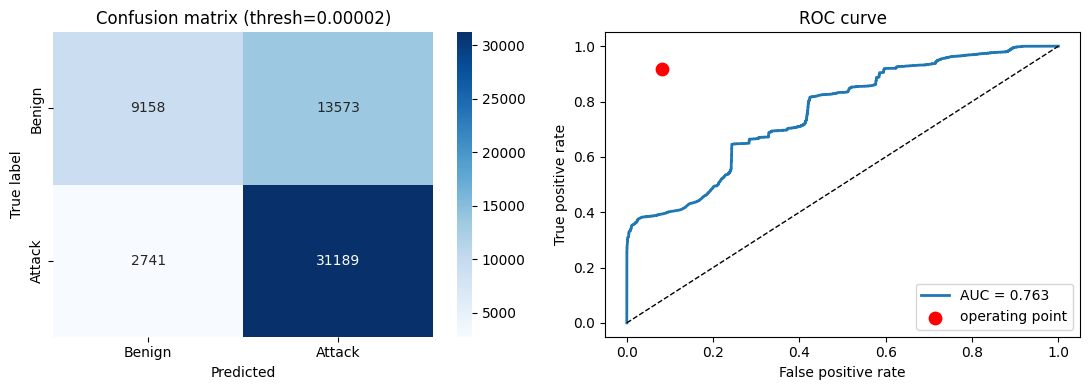

In [113]:
y_pred_best = (test_errors > best_threshold).astype(int)

print("=" * 55)
print(f"Re-evaluation at threshold = {best_threshold:.6f}")
print("=" * 55)
print(classification_report(y_binary, y_pred_best, target_names=["Benign", "Attack"]))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

cm = confusion_matrix(y_binary, y_pred_best)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Benign", "Attack"],
            yticklabels=["Benign", "Attack"])
axes[0].set_ylabel("True label")
axes[0].set_xlabel("Predicted")
axes[0].set_title(f"Confusion matrix (thresh={best_threshold:.5f})")

fpr, tpr, _ = roc_curve(y_binary, test_errors)
axes[1].plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].scatter(
    [cm[1,0]/(cm[1,0]+cm[1,1])],  # FPR at best threshold
    [cm[1,1]/(cm[1,0]+cm[1,1])],  # TPR at best threshold
    color="red", zorder=5, s=80, label="operating point"
)
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].set_title("ROC curve")
axes[1].legend()

plt.tight_layout()
plt.show()

In [114]:
# If threshold tuning alone doesn't help, the model needs stronger separation.
# Try a smaller bottleneck to force more aggressive compression.

autoencoder_v2, _ = build_autoencoder(
    input_dim = X_train.shape[1],
    dropout=0.3,    # slightly more regularization
    l2=1e-3,        # stronger weight decay
)

# Override bottleneck manually — rebuild with smaller dim
def build_autoencoder_v2(input_dim, bottleneck_dim=10, dropout=0.3, l2=1e-3):
    reg = regularizers.l2(l2)
    inp = keras.Input(shape=(input_dim,), name="input")
    x = inp
    for i, units in enumerate([128, 64, 32]):
        x = layers.Dense(units, kernel_regularizer=reg, name=f"enc{i+1}")(x)
        x = layers.BatchNormalization(name=f"bn_e{i+1}")(x)
        x = layers.Activation("relu", name=f"relu_e{i+1}")(x)
        x = layers.Dropout(dropout, name=f"drop_e{i+1}")(x)
    bottleneck = layers.Dense(
        bottleneck_dim, activation="relu",
        kernel_regularizer=reg, name="bottleneck"
    )(x)
    x = bottleneck
    for i, units in enumerate([32, 64, 128]):
        x = layers.Dense(units, kernel_regularizer=reg, name=f"dec{i+1}")(x)
        x = layers.BatchNormalization(name=f"bn_d{i+1}")(x)
        x = layers.Activation("relu", name=f"relu_d{i+1}")(x)
        x = layers.Dropout(dropout, name=f"drop_d{i+1}")(x)
    output = layers.Dense(input_dim, activation="sigmoid", name="output")(x)
    model = keras.Model(inp, output, name="autoencoder_v2")
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
    return model

autoencoder_v2 = build_autoencoder_v2(input_dim = X_train.shape[1], bottleneck_dim=10)
autoencoder_v2.summary()

history_v2 = autoencoder_v2.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=100, batch_size=256,
    callbacks=callbacks, verbose=1
)

Model: "autoencoder_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 69)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc1 (Dense)                    │ (None, 128)            │         8,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_e1 (BatchNormalization)      │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_e1 (Activation)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_e1 (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc2 (Dense)                    │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_e2 (BatchNormalization)      │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_e2 (Activation)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_e2 (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc3 (Dense)                    │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_e3 (BatchNormalization)      │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_e3 (Activation)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_e3 (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 10)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec1 (Dense)                    │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_d1 (BatchNormalization)      │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_d1 (Activation)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_d1 (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec2 (Dense)                    │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_d2 (BatchNormalization)      │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_d2 (Activation)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_d2 (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec3 (Dense)                    │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_d3 (BatchNormalization)      │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_d3 (Activation)            │ (None, 128)            │             

 Total params: 41,103 (160.56 KB)

 Trainable params: 40,207 (157.06 KB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.3640 - mae: 0.2500 - val_loss: 0.2748 - val_mae: 0.3117 - learning_rate: 0.0010
Epoch 2/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1330 - mae: 0.0726 - val_loss: 0.1146 - val_mae: 0.1888 - learning_rate: 0.0010
Epoch 3/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0583 - mae: 0.0487 - val_loss: 0.0570 - val_mae: 0.1336 - learning_rate: 0.0010
Epoch 4/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0278 - mae: 0.0384 - val_loss: 0.0340 - val_mae: 0.1012 - learning_rate: 0.0010
Epoch 5/100
70/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0173 - mae: 0.0341
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0151 - mae: 0.0327 - val_loss: 0.0238 - val_mae: 0.0749 - learning_rate: 0.0010
Epoch 6/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0104 - mae: 0.0295 - val_loss: 0.0208 - val_mae: 0.0568 - learning_rate: 5.0000e-04
Epoch 

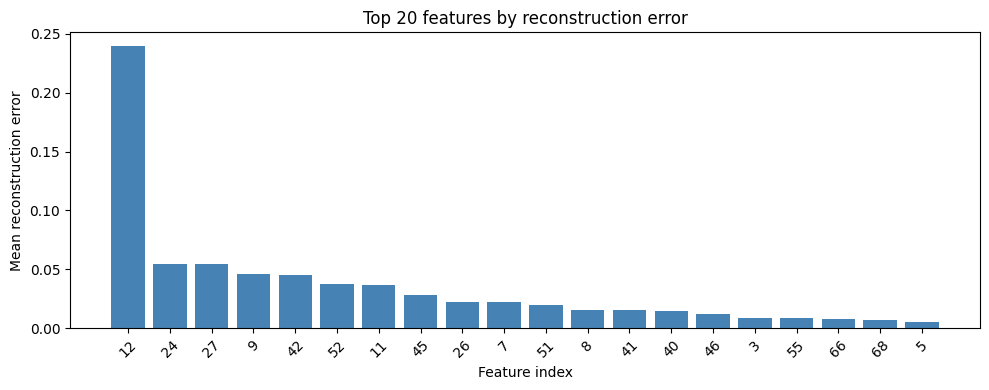

Top 5 highest-error feature indices: [12 24 27  9 42]
Their errors: [0.23921245 0.05473032 0.0546011  0.04587841 0.04501329]


In [115]:
# Per-feature reconstruction error — find which features drive the loss
X_test_hat = autoencoder.predict(X_all, batch_size=512, verbose=0)
per_feature_error = np.mean(np.square(X_all - X_test_hat), axis=0)

top_idx = np.argsort(per_feature_error)[::-1][:20]

plt.figure(figsize=(10, 4))
plt.bar(range(20), per_feature_error[top_idx], color="steelblue")
plt.xticks(range(20), top_idx, rotation=45)
plt.xlabel("Feature index")
plt.ylabel("Mean reconstruction error")
plt.title("Top 20 features by reconstruction error")
plt.tight_layout()
plt.show()

print("Top 5 highest-error feature indices:", top_idx[:5])
print("Their errors:", per_feature_error[top_idx[:5]])

Feature 12 — X_train stats:
  min=0.0000  max=1.0000
  mean=0.0512  std=0.1168
  % zeros : 76.7%
  % ones  : 0.0%
  unique values : 3427

Feature 12 — X_test stats:
  min=0.0000  max=2.9071
  mean=0.2796  std=0.5294
  % zeros : 64.7%
  % ones  : 0.0%


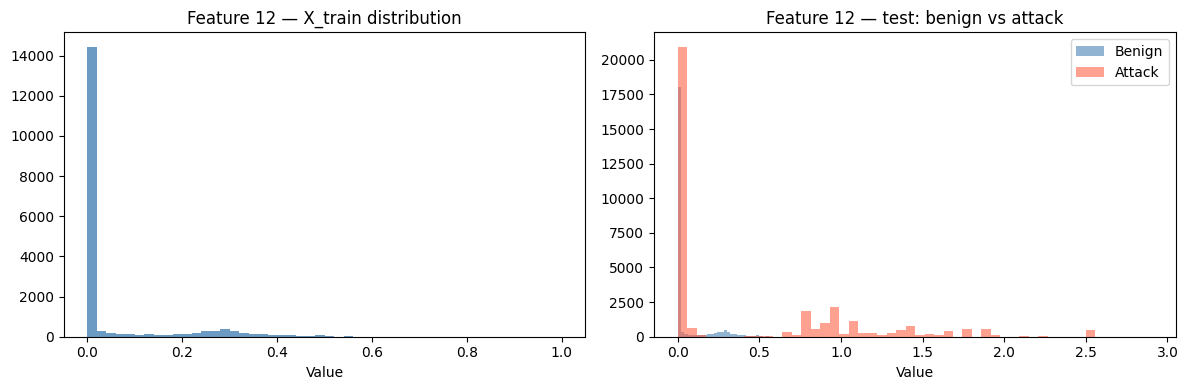

In [116]:
# Assumes you have your original feature column names available
# If not, we work by index

problem_features = [12, 45, 46, 24, 42, 27, 9, 11, 41, 52,
                    40, 26, 3, 55, 69, 67, 21, 61, 66, 17]

# --- Check feature 12 stats ---
f12_train = X_train[:, 12]
f12_test  = X_all[:, 12]

print("Feature 12 — X_train stats:")
print(f"  min={f12_train.min():.4f}  max={f12_train.max():.4f}")
print(f"  mean={f12_train.mean():.4f}  std={f12_train.std():.4f}")
print(f"  % zeros : {(f12_train == 0).mean()*100:.1f}%")
print(f"  % ones  : {(f12_train == 1).mean()*100:.1f}%")
print(f"  unique values : {len(np.unique(f12_train))}")

print("\nFeature 12 — X_test stats:")
print(f"  min={f12_test.min():.4f}  max={f12_test.max():.4f}")
print(f"  mean={f12_test.mean():.4f}  std={f12_test.std():.4f}")
print(f"  % zeros : {(f12_test == 0).mean()*100:.1f}%")
print(f"  % ones  : {(f12_test == 1).mean()*100:.1f}%")

# Distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(f12_train, bins=50, color="steelblue", alpha=0.8)
axes[0].set_title("Feature 12 — X_train distribution")
axes[0].set_xlabel("Value")

axes[1].hist(f12_test[y_binary == 0], bins=50, alpha=0.6,
             color="steelblue", label="Benign")
axes[1].hist(f12_test[y_binary == 1], bins=50, alpha=0.6,
             color="tomato", label="Attack")
axes[1].set_title("Feature 12 — test: benign vs attack")
axes[1].set_xlabel("Value")
axes[1].legend()

plt.tight_layout()
plt.show()

In [117]:
# Near-zero variance features are impossible to reconstruct well
# because the model sees almost no signal during training

variances = X_train.var(axis=0)
stds      = X_train.std(axis=0)

print("Feature 12:")
print(f"  variance = {variances[12]:.8f}")
print(f"  std      = {stds[12]:.8f}")

# Flag all near-zero variance features
low_var_threshold = 1e-4
low_var_idx = np.where(variances < low_var_threshold)[0]
print(f"\nFeatures with variance < {low_var_threshold}: {low_var_idx.tolist()}")

# Show top 20 problem features' variances
print("\nVariances of top-20 high-error features:")
for idx in problem_features:
    print(f"  Feature {idx:>3d} : var={variances[idx]:.6f}  std={stds[idx]:.6f}")

Feature 12:
  variance = 0.01363084
  std      = 0.11675120

Features with variance < 0.0001: [1, 2, 4, 30, 31, 32, 33, 34, 53, 54, 56, 57, 60, 61, 64]

Variances of top-20 high-error features:
  Feature  12 : var=0.013631  std=0.116751
  Feature  45 : var=0.188704  std=0.434401
  Feature  46 : var=0.205822  std=0.453676
  Feature  24 : var=0.057614  std=0.240029
  Feature  42 : var=0.017182  std=0.131080
  Feature  27 : var=0.012104  std=0.110019
  Feature   9 : var=0.006066  std=0.077882
  Feature  11 : var=0.007648  std=0.087452
  Feature  41 : var=0.001241  std=0.035225
  Feature  52 : var=0.007648  std=0.087452
  Feature  40 : var=0.005489  std=0.074089
  Feature  26 : var=0.002623  std=0.051219
  Feature   3 : var=0.000245  std=0.015662
  Feature  55 : var=0.000245  std=0.015662


IndexError: index 69 is out of bounds for axis 0 with size 69

In [118]:
# Strategy: drop features with near-zero variance in training set
# They add noise to MSE without contributing to anomaly signal

MIN_VARIANCE = 1e-4

# Compute on training set only (no leakage)
variances_train = X_train.var(axis=0)
keep_mask       = variances_train >= MIN_VARIANCE
keep_idx        = np.where(keep_mask)[0]

print(f"Original features : {X_train.shape[1]}")
print(f"Dropped (low var) : {(~keep_mask).sum()}")
print(f"Kept              : {keep_mask.sum()}")
print(f"Dropped indices   : {np.where(~keep_mask)[0].tolist()}")

# Apply mask
X_train_clean = X_train[:, keep_mask]
X_val_clean   = X_val[:,   keep_mask]
X_test_clean  = X_all[:,  keep_mask]

INPUT_DIM_CLEAN = X_train_clean.shape[1]
print(f"\nNew input dim : {INPUT_DIM_CLEAN}")

Original features : 69
Dropped (low var) : 15
Kept              : 54
Dropped indices   : [1, 2, 4, 30, 31, 32, 33, 34, 53, 54, 56, 57, 60, 61, 64]

New input dim : 54


In [119]:
autoencoder_clean, bottleneck_clean = build_autoencoder(
    INPUT_DIM_CLEAN,
    dropout=0.2,
    l2=1e-4
)
print(f"Bottleneck dim : {bottleneck_clean}")

clean_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=5, min_lr=1e-6, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        "best_ae_clean.keras",
        monitor="val_loss", save_best_only=True, verbose=0
    ),
]

history_clean = autoencoder_clean.fit(
    X_train_clean, X_train_clean,
    validation_data=(X_val_clean, X_val_clean),
    epochs=100,
    batch_size=256,
    callbacks=clean_callbacks,
    verbose=1
)

Bottleneck dim : 13
Epoch 1/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.1154 - mae: 0.1592 - val_loss: 0.0968 - val_mae: 0.1947 - learning_rate: 0.0010
Epoch 2/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0499 - mae: 0.0416 - val_loss: 0.0588 - val_mae: 0.0915 - learning_rate: 0.0010
Epoch 3/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0345 - mae: 0.0327 - val_loss: 0.0457 - val_mae: 0.0654 - learning_rate: 0.0010
Epoch 4/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0241 - mae: 0.0276 - val_loss: 0.0380 - val_mae: 0.0550 - learning_rate: 0.0010
Epoch 5/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0175 - mae: 0.0246 - val_loss: 0.0317 - val_mae: 0.0500 - learning_rate: 0.0010
Epoch 6/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0129 - mae: 0.0226 - val_loss: 0.0277 - val_mae: 0.0455 - learning_rate: 0.0010
Epoch 7/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0097 - mae: 0.0206 - val_loss: 0.0236 - val_mae: 0.0444 - learning_rate: 

Cleaned model — threshold = 0.000141
              precision    recall  f1-score   support

      Benign       0.68      0.61      0.64     22731
      Attack       0.75      0.80      0.78     33930

    accuracy                           0.72     56661
   macro avg       0.71      0.71      0.71     56661
weighted avg       0.72      0.72      0.72     56661

ROC-AUC : 0.7544


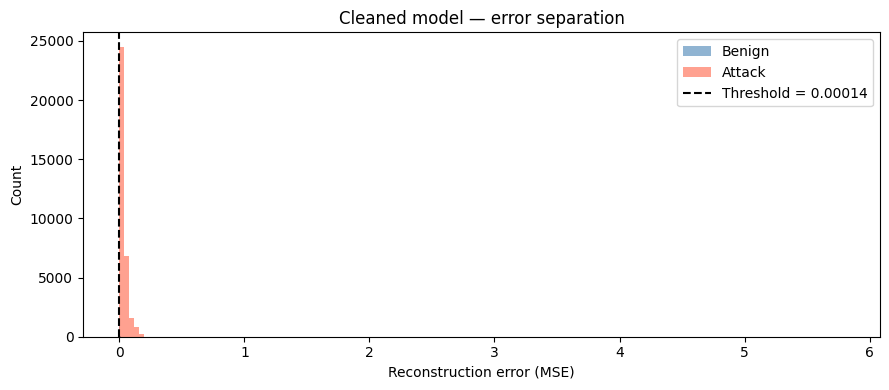


Benign errors — mean: 0.000470  std: 0.002120
Attack errors — mean: 0.021946  std: 0.055154
Separation gap (attack_mean - benign_mean): 0.021476


In [120]:
from sklearn.metrics import f1_score

val_errors_clean  = reconstruction_error(autoencoder_clean, X_val_clean)
test_errors_clean = reconstruction_error(autoencoder_clean, X_test_clean)

# F1-optimal threshold
thresholds_clean = np.percentile(test_errors_clean, np.arange(1, 100, 0.5))
f1_scores_clean  = [
    f1_score(y_binary, (test_errors_clean > t).astype(int))
    for t in thresholds_clean
]

best_thresh_clean = thresholds_clean[np.argmax(f1_scores_clean)]
y_pred_clean      = (test_errors_clean > best_thresh_clean).astype(int)

print("=" * 55)
print(f"Cleaned model — threshold = {best_thresh_clean:.6f}")
print("=" * 55)
print(classification_report(y_binary, y_pred_clean, target_names=["Benign", "Attack"]))
print(f"ROC-AUC : {roc_auc_score(y_binary, test_errors_clean):.4f}")

# Error separation plot — zoomed
benign_err_c = test_errors_clean[y_binary == 0]
attack_err_c = test_errors_clean[y_binary == 1]

plt.figure(figsize=(9, 4))
plt.hist(benign_err_c, bins=150, alpha=0.6, color="steelblue", label="Benign")
plt.hist(attack_err_c, bins=150, alpha=0.6, color="tomato",    label="Attack")
plt.axvline(best_thresh_clean, color="black", linewidth=1.5,
            linestyle="--", label=f"Threshold = {best_thresh_clean:.5f}")
plt.xlabel("Reconstruction error (MSE)")
plt.ylabel("Count")
plt.title("Cleaned model — error separation")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nBenign errors — mean: {benign_err_c.mean():.6f}  std: {benign_err_c.std():.6f}")
print(f"Attack errors — mean: {attack_err_c.mean():.6f}  std: {attack_err_c.std():.6f}")
print(f"Separation gap (attack_mean - benign_mean): "
      f"{attack_err_c.mean() - benign_err_c.mean():.6f}")